# Build the Ansatz

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
sim = AerSimulator()

import sys
sys.path.append("../src")
from encoding import encode_data

In [2]:
iris = load_iris()
X_2class = iris.data[:100]
y_2class = iris.target[:100]
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_2class)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_2class, test_size=0.2, random_state=42)

## Parameters

### ParameterVector Exploration

In [3]:
theta = ParameterVector("theta", 4)
print(theta)
print([theta[i] for i in range(4)])
print(type(theta[0]))

theta, ['theta[0]', 'theta[1]', 'theta[2]', 'theta[3]']
[ParameterVectorElement(theta[0]), ParameterVectorElement(theta[1]), ParameterVectorElement(theta[2]), ParameterVectorElement(theta[3])]
<class 'qiskit._accelerate.circuit.ParameterVectorElement'>


Circuit with unbound parameters


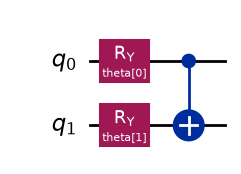

In [4]:
# test with unbound params
qc_test = QuantumCircuit(2)
theta_test = ParameterVector("theta", 2)

qc_test.ry(theta_test[0], 0)
qc_test.ry(theta_test[1], 1)
qc_test.cx(0, 1)

print("Circuit with unbound parameters")
qc_test.draw("mpl")

Circuit with bound parameters


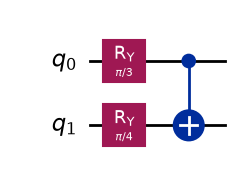

In [5]:
# test with bound parameters
bc_test = qc_test.assign_parameters({theta_test[0]: np.pi/3, theta_test[1]: np.pi/4})
print("Circuit with bound parameters")
bc_test.draw("mpl")

## Build one layer

In [119]:
def build_ansatz(n_qubits=4, n_layers=1):
    '''
    Requires: 
        n_qubits: int
            number of qubits (default 4 Iris dataset features)
        n_layers: int
            number of layers (default 1)
    Returns: 
        qc: QuantumCircuit
            unmeasured quantum circuit
        theta: ParameterVector
            parameter vector w/ length n_qubits * n_layers
    '''
    qc = QuantumCircuit(n_qubits)
    theta = ParameterVector('theta', n_qubits * n_layers)

    idx = 0
    for _ in range(n_layers):
        # Rotation layer
        # apply Ry gate to each qubit as trainable weights
        for qubit in range(n_qubits):
            qc.ry(theta[idx], qubit)
            idx+=1
        
        # Entanglement layer
        # CNOT staircase ending at qubit 0, the measured qubit
        # creates correlation between all qubits
        for qubit in reversed(range(1, n_qubits)):
            qc.cx(qubit, qubit-1)
    
        qc.barrier()

    return qc, theta

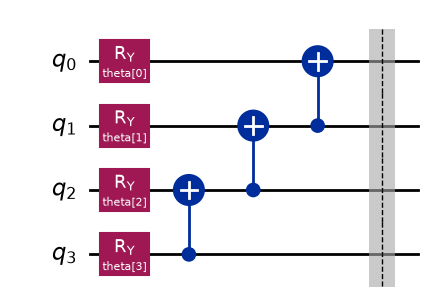

In [120]:
# test on 1-layer ansatz
ansatz_1, theta_1 = build_ansatz(n_qubits=4, n_layers=1)
ansatz_1.draw('mpl')

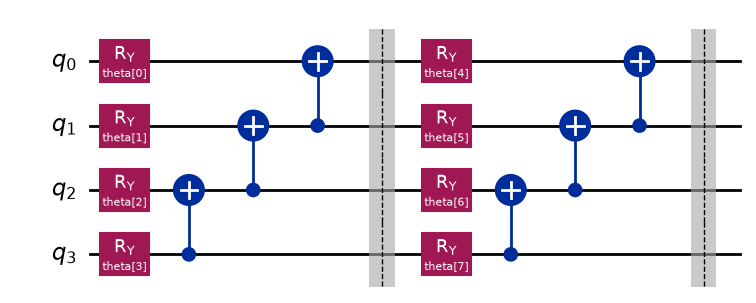

In [121]:
# test on 2-layer ansatz
ansatz_2, theta_2 = build_ansatz(n_qubits=4, n_layers=2)
ansatz_2.draw('mpl')

# Full VQC Circuit
encoding - ansatz - measurement

In [122]:
def build_vqc(x, n_layers=1):
    '''
    Requires:
        x: array-like w/ length 4 (in the case of the Iris dataset)
            length = number of qubits
        n_layers: int
            number of ansatz layers, default 1

    Returns:
        circuit: QuantumCircuit
            full vqc w/ encoding, ansatz, and measurement on qubit 0
        theta: ParameterVector
            trainable parameters w/ length len(x) * n_layers
    '''
    qc_enc = encode_data(x)
    ansatz, theta = build_ansatz(len(x), n_layers)

    circuit = QuantumCircuit(len(x), 1)

    circuit.compose(qc_enc, inplace=True)
    circuit.compose(ansatz, inplace=True)
    circuit.measure(0, 0)

    return circuit, theta

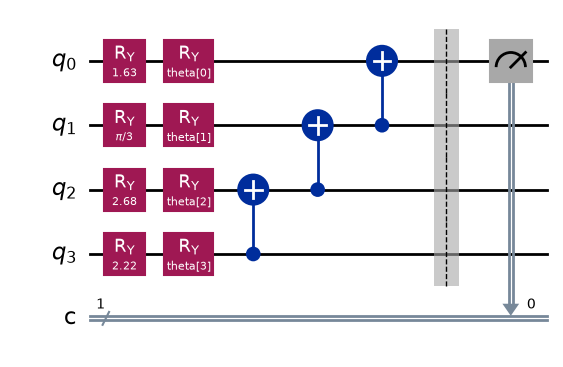

theta, ['theta[0]', 'theta[1]', 'theta[2]', 'theta[3]']


In [123]:
# test on training sample
qc_test, theta_test = build_vqc(X_train[0], 1)
display(qc_test.draw('mpl'))
print(theta_test)

## Notes
First column of R_y gates is encoded parameters, shown in the circuit as fixed decimal numbers. 
Second column of R_y gates is trainable parameters, the first part of the ansatz layer that will be adjusted to optimize results.
Four CNOT gates (n_qubits - 1) is the second part of the ansatz layer and entangles the qubits.
Then we can measure the whole circuit as one quantum unit, collapsing onto a classical bit that gives us the result. In this case we only measure q0 because we only need one scalar answer - the type of iris.

Also - should test the number of layers to find the optimum for performance. Overusing layers will lead to barren plateau.

# Classifier Confidence

In [124]:
def get_prob(qc, theta, theta_vals, shots=1000):
    '''
    Effect:
        Finds the probability of a parameterized VQC returning |1>
    Requires:
        qc: QuantumCircuit
            measured quantum circuit built by build_vqc
        theta: ParameterVector
            parameters used in qc
        theta_vals: array-like w/ length = len(theta)
            values to bind to the parameters
        shots: int
            number of runs; default 1000
    '''
    param_dict = dict(zip(theta, theta_vals))
    bound_qc = qc.assign_parameters(param_dict)

    job = sim.run(bound_qc, shots=shots)
    counts = job.result().get_counts()

    return counts.get('1', 0) / shots

In [125]:
qc_test, theta_test = build_vqc(X_train[0], 1)
random_theta = np.random.uniform(0, 2 * np.pi, len(theta_test)) # random parameters_vals to test against

p = get_prob(qc_test, theta_test, random_theta, 1000)
print(f"True label: {y_train[0]} | Prob. of getting |1>: {p}")

True label: 1 | Prob. of getting |1>: 0.476


In [127]:
# test multiple circuit runs on the same random parameter value set
print(f"{'Sample':>8} | {'True label':>10} | {'P(|1>)':>8} | {'Predicted':>10} | {'Correct':>8}")
print("-" * 58)

n_runs = 10
correct = 0
for i in range(n_runs):
    qc_i, theta_i = build_vqc(X_train[i], n_layers=1)
    p = get_prob(qc_i, theta_i, random_theta, shots=500)
    pred = int(p > 0.5)
    is_correct = pred == y_train[i]
    correct += is_correct
    print(f"{i:>8} | {y_train[i]:>10} | {p:>8.3f} | {pred:>10} | {'✓' if is_correct else '✗':>8}")

print(f"accuracy with random params: {correct}/{n_runs}")
# expected ~50% — random parameters should classify randomly

  Sample | True label |   P(|1>) |  Predicted |  Correct
----------------------------------------------------------
       0 |          1 |    0.492 |          0 |        ✗
       1 |          1 |    0.470 |          0 |        ✗
       2 |          0 |    0.340 |          0 |        ✓
       3 |          0 |    0.434 |          0 |        ✓
       4 |          1 |    0.494 |          0 |        ✗
       5 |          0 |    0.370 |          0 |        ✓
       6 |          0 |    0.222 |          0 |        ✓
       7 |          1 |    0.518 |          1 |        ✓
       8 |          0 |    0.412 |          0 |        ✓
       9 |          1 |    0.490 |          0 |        ✗
accuracy with random params: 6/10


## Tests

In [128]:
# extreme theta binding parameters test
qc_test1, theta_test1 = build_vqc(np.zeros(4), 1)

# theta = 0: ansatz R_y gates do nothing
p_zero = get_prob(qc_test1, theta_test1, np.zeros(4), shots=1000)

# theta = pi: ansatz R_y gates always flip
p_pi = get_prob(qc_test1, theta_test1, np.full(4, np.pi), shots=1000)

# theta = random: control
random_theta = np.random.uniform(0, 2 * np.pi, len(theta_test1))
p_rand = get_prob(qc_test1, theta_test1, random_theta, shots=1000)

print(f"All thetas = 0: P(|1>) = {p_zero}") # near 0%
print(f"All thetas = pi: P(|1>) = {p_pi}") # near 100%
print(f"Control - random thetas: P(|1>) = {p_rand}") # random

All thetas = 0: P(|1>) = 0.0
All thetas = pi: P(|1>) = 0.0
Control - random thetas: P(|1>) = 0.654


In [129]:
# stress test for stability check
qc_test2, theta_test2 = build_vqc(X_train[0], 1)
random_theta = np.random.uniform(0, 2 * np.pi, len(theta_test2))
probs = [get_prob(qc_test2, theta_test2, random_theta, shots=1000)
         for _ in range(10)]

print(f"Probs: {[round(p, 3) for p in probs]}")
print(f"Mean: {np.mean(probs)}")
print(f"Std: {np.std(probs)}")
# small standard deviation ~0.01; more shots = more stable

Probs: [0.472, 0.466, 0.463, 0.428, 0.424, 0.475, 0.467, 0.465, 0.454, 0.47]
Mean: 0.4584
Std: 0.017083325203250097


In [130]:
# different probs for different samples - encoding works properly
for i in range(5):
    qc_test_i, theta_test_i = build_vqc(X_train[i], 1)
    random_theta_i = np.random.uniform(0, 2 * np.pi, len(theta_test_i))
    prob_i = get_prob(qc_test_i, theta_test_i, random_theta_i, 1000)
    print(f"Sample {i} (class {y_train[i]}): P(|1>) = {prob_i}")

Sample 0 (class 1): P(|1>) = 0.32
Sample 1 (class 1): P(|1>) = 0.487
Sample 2 (class 0): P(|1>) = 0.465
Sample 3 (class 0): P(|1>) = 0.647
Sample 4 (class 1): P(|1>) = 0.437


## Notes
Classifier is currently untrained so the probabilities are all over the place.

## Circuit Depth Tests

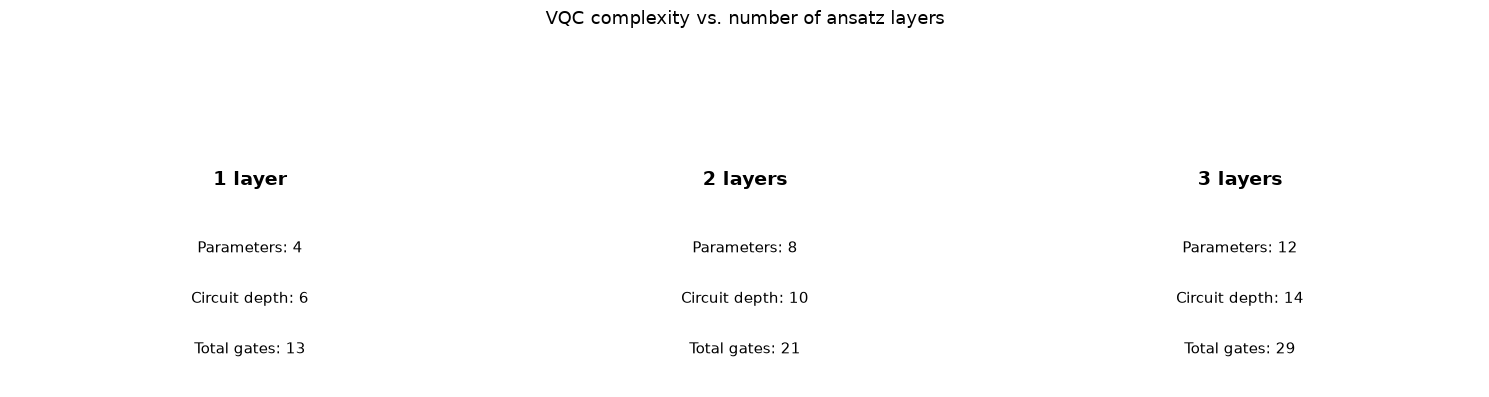

In [131]:
# check how the number of layers affects the result
# test for 1 vs. 2 vs. 3 layers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, n_layers in enumerate([1, 2, 3]):
    qc, theta = build_vqc(X_train[0], n_layers=n_layers)
    depth = qc.depth()
    n_params = len(theta)
    n_gates = sum(qc.count_ops().values())

    axes[i].axis('off')
    axes[i].text(0.5, 0.6, f"{n_layers} layer{'s' if n_layers > 1 else ''}",
                 ha='center', fontsize=14, fontweight='bold',
                 transform=axes[i].transAxes)
    axes[i].text(0.5, 0.4, f"Parameters: {n_params}",
                 ha='center', fontsize=11, transform=axes[i].transAxes)
    axes[i].text(0.5, 0.25, f"Circuit depth: {depth}",
                 ha='center', fontsize=11, transform=axes[i].transAxes)
    axes[i].text(0.5, 0.1, f"Total gates: {n_gates}",
                 ha='center', fontsize=11, transform=axes[i].transAxes)

plt.suptitle("VQC complexity vs. number of ansatz layers", fontsize=13)
plt.tight_layout()
plt.savefig("../results/circuit_depth_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

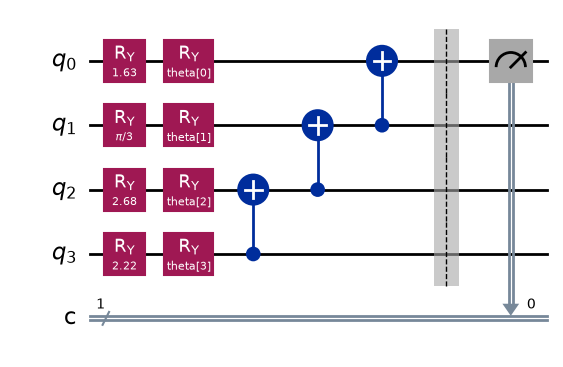

In [132]:
qc_final, _ = build_vqc(X_train[0], n_layers=1)
fig = qc_final.draw('mpl', fold=40)
fig.savefig("../results/vqc_circuit_diagram.png", dpi=150, bbox_inches='tight')
display(fig)